# Pulsar Classification with PyTorch

This notebook implements a pulsar classification system using PyTorch with a Transformer-based architecture.

## Features:
- **Data Exploration**: Comprehensive EDA with visualizations (pie chart, correlation heatmap, pairplot)
- **Model Architecture**: Transformer Encoder with multi-head attention mechanism
- **Training**: 100 epochs with early stopping, class weights for imbalanced data
- **Evaluation**: Confusion matrix, accuracy, recall, F1-score
- **Robustness Analysis**: Noise sensitivity testing
- **Interactive Demo**: Gradio web interface for predictions

## Model Architecture:
- Input Layer: 8 features → 16 dimensions
- Transformer Encoder:
  - Multi-head Attention (4 heads)
  - Feed-forward Network (32 dimensions)
  - Layer Normalization and Dropout (0.25)
- Output Layer: Binary classification with sigmoid activation

## Dataset:
HTRU (High Time Resolution Universe) Pulsar Dataset
- 17,898 samples
- 8 features (mean, std, kurtosis, skewness of profile and DM-SNR curve)
- Binary classification: Pulsar (1) vs Non-Pulsar (0)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import gradio as gr
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from prettytable import PrettyTable
from xgboost import XGBClassifier
from joblib import dump, load

In [2]:
# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

Device: cuda
GPU: NVIDIA GeForce RTX 2060
CUDA Version: 12.8


In [3]:
df = pd.read_csv("data/HTRU.csv")
df.head()

,140.5625,55.68378214,-0.234571412,-0.699648398,3.199832776,19.11042633,7.975531794,74.24222492,0
0,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
1,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
2,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
3,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0
4,93.570312,46.698114,0.531905,0.416721,1.636288,14.545074,10.621748,131.394004,0


In [4]:
df.columns = [
    "mean_profile",
    "std_profile",
    "kurtosis_profile",
    "skewness_profile",
    "mean_dmsc",
    "std_dmsc",
    "kurtosis_dmsc",
    "skewness_dmsc",
    "target",
]

In [5]:
df.isna().sum()

mean_profile        0
std_profile         0
kurtosis_profile    0
skewness_profile    0
mean_dmsc           0
std_dmsc            0
kurtosis_dmsc       0
skewness_dmsc       0
target              0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17897 entries, 0 to 17896
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mean_profile      17897 non-null  float64
 1   std_profile       17897 non-null  float64
 2   kurtosis_profile  17897 non-null  float64
 3   skewness_profile  17897 non-null  float64
 4   mean_dmsc         17897 non-null  float64
 5   std_dmsc          17897 non-null  float64
 6   kurtosis_dmsc     17897 non-null  float64
 7   skewness_dmsc     17897 non-null  float64
 8   target            17897 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


In [7]:
df.describe()

,mean_profile,std_profile,kurtosis_profile,skewness_profile,mean_dmsc,std_dmsc,kurtosis_dmsc,skewness_dmsc,target
count,17897.000000,17897.000000,17897.000000,17897.000000,17897.000000,17897.000000,17897.000000,17897.000000,17897.00000
mean,111.078321,46.549021,0.477897,1.770417,12.614926,26.326918,8.303574,104.859419,0.09158
std,25.652705,6.843040,1.064056,6.168058,29.473637,19.471042,4.506217,106.517270,0.28844
min,5.812500,24.772042,-1.876011,-1.791886,0.213211,7.370432,-3.139270,-1.976976,0.00000
25%,100.929688,42.375426,0.027108,-0.188528,1.923077,14.437330,5.781485,34.957119,0.00000
50%,115.078125,46.946435,0.223241,0.198736,2.801839,18.459977,8.433872,83.068996,0.00000
75%,127.085938,51.022887,0.473349,0.928206,5.464883,28.428152,10.702973,139.310905,0.00000
max,192.617188,98.778911,8.069522,68.101622,223.392141,110.642211,34.539844,1191.000837,1.00000


In [8]:
pulsar = df[df["target"] == 1]
pulsar_count = pulsar["target"].value_counts()[1]
non_pul = df[df["target"] == 0]
nonpul_count = non_pul["target"].value_counts()[0]

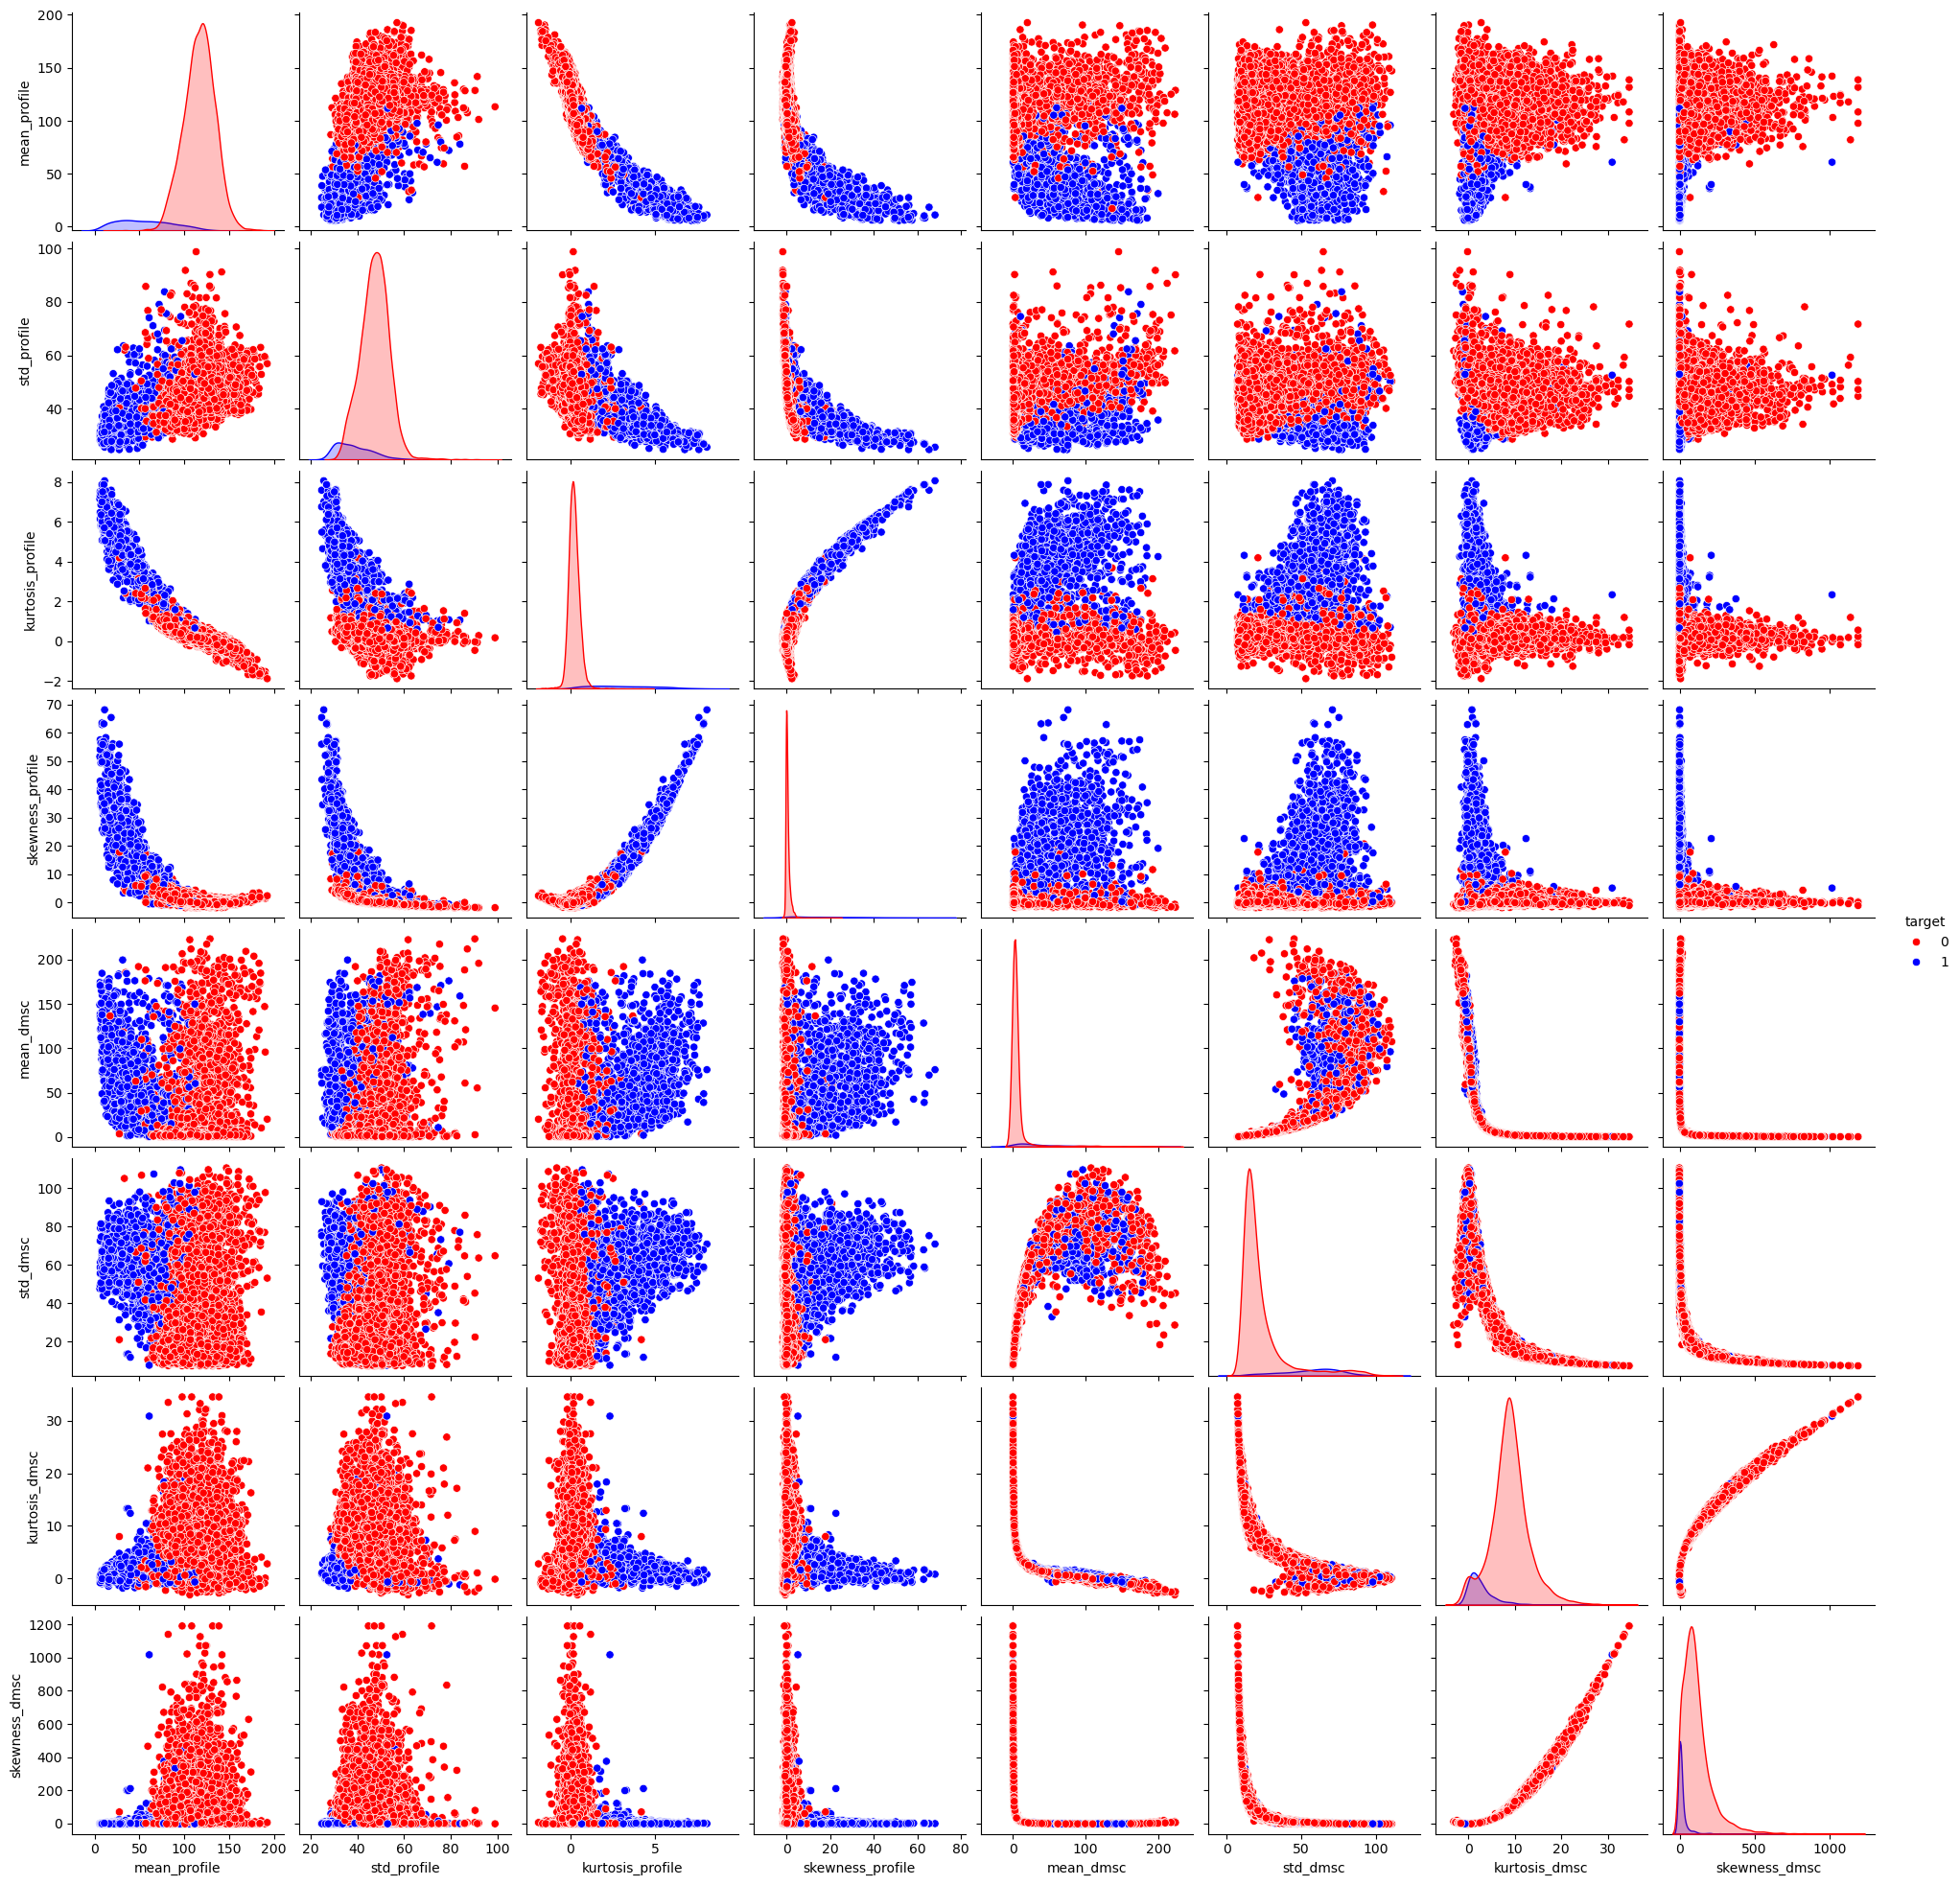

In [9]:
# Pairplot for feature relationships
sns.pairplot(df, hue="target", palette=["red", "blue"])
plt.show()

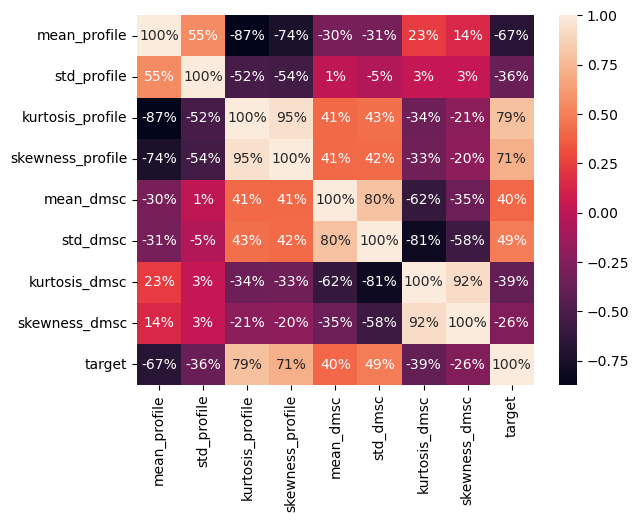

In [10]:
# Correlation heatmap
sns.heatmap(df.iloc[:, 0:9].corr(), annot=True, fmt=".0%")
plt.show()

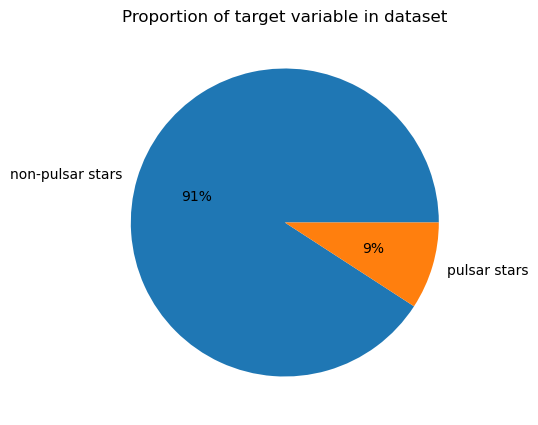

There are 1639 signals that belong to pulsar stars and 16258 signals that aren't from pulsars.


In [11]:
# Pie chart plotting the stats between pulsars and not pulsars
plt.figure(figsize=(5, 5))
plt.pie(
    df["target"].value_counts().values,
    labels=["non-pulsar stars", "pulsar stars"],
    autopct="%1.0f%%",
)
plt.title("Proportion of target variable in dataset")
plt.show()
print(
    "There are "
    + str(pulsar_count)
    + " signals that belong to pulsar stars "
    + "and "
    + str(nonpul_count)
    + " signals that aren't from pulsars."
)

In [ ]:
# Data preparation (no leakage): train/val/test split + fit scaler on train only

# Select first 8 columns as features
features = df.iloc[:, 0:8]
target = df.iloc[:, 8]

# 1) Split off TEST set (kept untouched until final evaluation)
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    features,
    target,
    test_size=0.2,  # keep consistent with TF notebook
    stratify=target,
    random_state=42,
 )

# 2) Split TRAIN into TRAIN/VAL (used for monitoring during training)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw,
    y_train_raw,
    test_size=0.25,  # 20% of remaining 65% => 13% of total as validation
    stratify=y_train_raw,
    random_state=42,
 )

# Fit scaler ONLY on training data to avoid leakage
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

# Report split sizes and class ratios
def _ratio(y):
    y = np.asarray(y)
    return float((y == 1).mean())

print(f"Train size: {len(X_train)} | pos ratio: {_ratio(y_train):.4f}")
print(f"Val size:   {len(X_val)} | pos ratio: {_ratio(y_val):.4f}")
print(f"Test size:  {len(X_test)} | pos ratio: {_ratio(y_test):.4f}")

# Compute class imbalance from TRAIN only (data-driven)
neg_train = int((y_train == 0).sum())
pos_train = int((y_train == 1).sum())
pos_weight_value = neg_train / max(pos_train, 1)
print(f"Train neg/pos: {pos_weight_value:.4f}")

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(np.asarray(y_train), dtype=torch.float32).unsqueeze(1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(np.asarray(y_val), dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(np.asarray(y_test), dtype=torch.float32).unsqueeze(1)

# Create DataLoader for training
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)  # tune batch_size as needed

Train size: 9306 | pos ratio: 0.0916
Val size:   2327 | pos ratio: 0.0915
Test size:  6264 | pos ratio: 0.0916
Train neg/pos: 9.9225


In [13]:
# Validation DataLoader (for monitoring)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=4096, shuffle=False)

In [14]:
# Define PyTorch models (Original vs Improved) - Adam only

# ============= RMSNorm Implementation =============
class RMSNorm(nn.Module):
    """Root Mean Square Layer Normalization - faster than LayerNorm"""

    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        rms = torch.sqrt(torch.mean(x**2, dim=-1, keepdim=True) + self.eps)
        x_normalized = x / rms
        return self.weight * x_normalized


# ============= SwiGLU Activation Implementation =============
class SwiGLU(nn.Module):
    """SwiGLU activation - often better than ReLU for convergence"""

    def __init__(self, dim_in, dim_out):
        super().__init__()
        self.w1 = nn.Linear(dim_in, dim_out)
        self.w2 = nn.Linear(dim_in, dim_out)

    def forward(self, x):
        return nn.functional.silu(self.w1(x)) * self.w2(x)


# ============= Original Transformer Encoder =============
class TransformerEncoder(nn.Module):
    """Original Transformer Encoder with LayerNorm and ReLU"""

    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.25):
        super().__init__()
        self.attention = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout_rate, batch_first=True
        )
        self.norm1 = nn.LayerNorm(embed_dim, eps=1e-6)
        self.norm2 = nn.LayerNorm(embed_dim, eps=1e-6)

        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(ff_dim, embed_dim),
        )
        self.dropout1 = nn.Dropout(dropout_rate)
        self.dropout2 = nn.Dropout(dropout_rate)

    def forward(self, x):
        attn_output, _ = self.attention(x, x, x)
        attn_output = self.dropout1(attn_output)
        x = self.norm1(x + attn_output)

        ff_output = self.ff(x)
        ff_output = self.dropout2(ff_output)
        x = self.norm2(x + ff_output)
        return x


# ============= Improved Transformer Encoder with RMSNorm + SwiGLU =============
class ImprovedTransformerEncoder(nn.Module):
    """Improved Transformer Encoder with RMSNorm and SwiGLU"""

    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.25):
        super().__init__()
        self.attention = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout_rate, batch_first=True
        )
        self.norm1 = RMSNorm(embed_dim)
        self.norm2 = RMSNorm(embed_dim)

        self.swiglu = SwiGLU(embed_dim, ff_dim)
        self.ff_out = nn.Linear(ff_dim, embed_dim)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.dropout2 = nn.Dropout(dropout_rate)

    def forward(self, x):
        attn_output, _ = self.attention(x, x, x)
        attn_output = self.dropout1(attn_output)
        x = self.norm1(x + attn_output)

        ff_output = self.swiglu(x)
        ff_output = self.ff_out(ff_output)
        ff_output = self.dropout2(ff_output)
        x = self.norm2(x + ff_output)
        return x


# ============= Base Pulsar Model =============
class PulsarModel(nn.Module):
    """Original Pulsar classification model (outputs logits)"""

    def __init__(self, input_dim=8, embed_dim=16, num_heads=4, ff_dim=32, dropout=0.25):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, embed_dim)
        self.dropout1 = nn.Dropout(dropout)
        self.transformer = TransformerEncoder(embed_dim, num_heads, ff_dim, dropout)
        self.fc_out = nn.Linear(embed_dim, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = x.unsqueeze(1)
        x = self.transformer(x)
        x = x.squeeze(1)
        logits = self.fc_out(x)
        return logits


# ============= Improved Pulsar Model =============
class ImprovedPulsarModel(nn.Module):
    """Improved Pulsar model with RMSNorm and SwiGLU (outputs logits)"""

    def __init__(self, input_dim=8, embed_dim=16, num_heads=4, ff_dim=32, dropout=0.25):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, embed_dim)
        self.dropout1 = nn.Dropout(dropout)
        self.transformer = ImprovedTransformerEncoder(
            embed_dim, num_heads, ff_dim, dropout
        )
        self.fc_out = nn.Linear(embed_dim, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = x.unsqueeze(1)
        x = self.transformer(x)
        x = x.squeeze(1)
        logits = self.fc_out(x)
        return logits


# ============= Initialize Two Models =============
print("=" * 70)
print("MODEL INITIALIZATION - TWO-WAY COMPARISON")
print("=" * 70)

model_original = PulsarModel(
    input_dim=8, embed_dim=16, num_heads=4, ff_dim=32, dropout=0.25
).to(device)
model_improved = ImprovedPulsarModel(
    input_dim=8, embed_dim=16, num_heads=4, ff_dim=32, dropout=0.25
).to(device)

print("\n✓ Model 1: Original (LayerNorm + ReLU + Adam)")
print(f"  Parameters: {sum(p.numel() for p in model_original.parameters()):,}")

print("\n✓ Model 2: Improved (RMSNorm + SwiGLU + Adam)")
print(f"  Parameters: {sum(p.numel() for p in model_improved.parameters()):,}")

# Optimizers
optimizer_original = optim.Adam(model_original.parameters(), lr=0.001)
optimizer_improved = optim.Adam(model_improved.parameters(), lr=0.001)

# Weighted loss (logits-based)
pos_weight_tensor = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

print("\n✓ Training Configuration:")
print(f"  Device: {device}")
print(f"  Loss Function: BCEWithLogitsLoss(pos_weight={pos_weight_value:.4f})")
print("  Optimizers:")
print("    → Model 1: Adam (lr=0.001)")
print("    → Model 2: Adam (lr=0.001)")
print("  Early Stopping: Disabled")
print("=" * 70)

MODEL INITIALIZATION - TWO-WAY COMPARISON

✓ Model 1: Original (LayerNorm + ReLU + Adam)
  Parameters: 2,385

✓ Model 2: Improved (RMSNorm + SwiGLU + Adam)
  Parameters: 2,897

✓ Training Configuration:
  Device: cuda
  Loss Function: BCEWithLogitsLoss(pos_weight=9.9225)
  Optimizers:
    → Model 1: Adam (lr=0.001)
    → Model 2: Adam (lr=0.001)
  Early Stopping: Disabled


In [15]:
# Print detailed model architectures (two models only)
print("\n" + "=" * 70)
print("MODEL 1: ORIGINAL ARCHITECTURE (LayerNorm + ReLU + Adam)")
print("=" * 70)
print(model_original)

print("\n" + "=" * 70)
print("MODEL 2: IMPROVED ARCHITECTURE (RMSNorm + SwiGLU + Adam)")
print("=" * 70)
print(model_improved)


MODEL 1: ORIGINAL ARCHITECTURE (LayerNorm + ReLU + Adam)
PulsarModel(
  (fc1): Linear(in_features=8, out_features=16, bias=True)
  (dropout1): Dropout(p=0.25, inplace=False)
  (transformer): TransformerEncoder(
    (attention): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
    )
    (norm1): LayerNorm((16,), eps=1e-06, elementwise_affine=True)
    (norm2): LayerNorm((16,), eps=1e-06, elementwise_affine=True)
    (ff): Sequential(
      (0): Linear(in_features=16, out_features=32, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.25, inplace=False)
      (3): Linear(in_features=32, out_features=16, bias=True)
    )
    (dropout1): Dropout(p=0.25, inplace=False)
    (dropout2): Dropout(p=0.25, inplace=False)
  )
  (fc_out): Linear(in_features=16, out_features=1, bias=True)
)

MODEL 2: IMPROVED ARCHITECTURE (RMSNorm + SwiGLU + Adam)
ImprovedPulsarModel(
  (fc1): Linear(in_features=8, out_features=16, bias=True)
  (drop

In [16]:
# Training loop - Compare TWO models (NO Early Stopping)
import time

epochs = 100  # Full training without early stopping

# Track training history for both models
history_original = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "epoch_time": [],
}
history_improved = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "epoch_time": [],
}

print("\n" + "=" * 70)
print("TWO-WAY COMPARATIVE TRAINING (Original vs Improved)")
print("=" * 70)
print("Active Models:")
print("  1️⃣  Original: LayerNorm + ReLU + Adam(lr=0.001)")
print("  2️⃣  Improved: RMSNorm + SwiGLU + Adam(lr=0.001)")
print(f"\nTraining: {epochs} epochs (No Early Stopping)")
print(f"Batch Size: {train_loader.batch_size}")
print("=" * 70 + "\n")

def evaluate_on_loader(model, loader):
    model.eval()
    loss_sum = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            loss = criterion(logits, labels)
            loss_sum += loss.item() * labels.size(0)
            preds = (logits > 0).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return loss_sum / max(total, 1), correct / max(total, 1)

for epoch in range(epochs):
    epoch_start = time.time()

    # ==================== TRAIN MODEL 1: ORIGINAL ====================
    model_original.train()
    train_loss_sum_orig = 0.0
    correct_orig = 0
    total_orig = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_original.zero_grad()
        logits = model_original(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer_original.step()

        train_loss_sum_orig += loss.item() * labels.size(0)
        preds = (logits > 0).float()
        correct_orig += (preds == labels).sum().item()
        total_orig += labels.size(0)

    avg_train_loss_orig = train_loss_sum_orig / max(total_orig, 1)
    train_acc_orig = correct_orig / max(total_orig, 1)

    # Validation for original model (VAL set)
    val_loss_orig, val_acc_orig = evaluate_on_loader(model_original, val_loader)

    # ==================== TRAIN MODEL 2: IMPROVED (Adam) ====================
    model_improved.train()
    train_loss_sum_imp = 0.0
    correct_imp = 0
    total_imp = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_improved.zero_grad()
        logits = model_improved(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer_improved.step()

        train_loss_sum_imp += loss.item() * labels.size(0)
        preds = (logits > 0).float()
        correct_imp += (preds == labels).sum().item()
        total_imp += labels.size(0)

    avg_train_loss_imp = train_loss_sum_imp / max(total_imp, 1)
    train_acc_imp = correct_imp / max(total_imp, 1)

    # Validation for improved model (VAL set)
    val_loss_imp, val_acc_imp = evaluate_on_loader(model_improved, val_loader)

    epoch_time = time.time() - epoch_start

    # Store history
    history_original["train_loss"].append(avg_train_loss_orig)
    history_original["train_acc"].append(train_acc_orig)
    history_original["val_loss"].append(val_loss_orig)
    history_original["val_acc"].append(val_acc_orig)
    history_original["epoch_time"].append(epoch_time)

    history_improved["train_loss"].append(avg_train_loss_imp)
    history_improved["train_acc"].append(train_acc_imp)
    history_improved["val_loss"].append(val_loss_imp)
    history_improved["val_acc"].append(val_acc_imp)
    history_improved["epoch_time"].append(epoch_time)

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch + 1}/{epochs}] - Time: {epoch_time:.2f}s")
        print(
            f"  1️⃣  ORIGINAL → Train: {avg_train_loss_orig:.4f}/{train_acc_orig:.4f} | Val: {val_loss_orig:.4f}/{val_acc_orig:.4f}"
        )
        print(
            f"  2️⃣  IMPROVED → Train: {avg_train_loss_imp:.4f}/{train_acc_imp:.4f} | Val: {val_loss_imp:.4f}/{val_acc_imp:.4f}"
        )
        print("-" * 70)

print("\n" + "=" * 70)
print("TWO-WAY COMPARATIVE TRAINING COMPLETED!")
print("=" * 70)
print("Total training time:")
print(f"  1️⃣  Original (Adam):             {sum(history_original['epoch_time']):.2f}s")
print(f"  2️⃣  Improved (Adam):             {sum(history_improved['epoch_time']):.2f}s")
print("\nFinal Validation Results:")
print(
    f"  1️⃣  Original → Loss: {history_original['val_loss'][-1]:.4f}, Acc: {history_original['val_acc'][-1]:.4f}"
)
print(
    f"  2️⃣  Improved → Loss: {history_improved['val_loss'][-1]:.4f}, Acc: {history_improved['val_acc'][-1]:.4f}"
)
print("\n💡 Comparing RMSNorm+SwiGLU vs LayerNorm+ReLU with same optimizer (Adam)")
print(f"   Batch Size: {train_loader.batch_size}")
print("=" * 70)


TWO-WAY COMPARATIVE TRAINING (Original vs Improved)
Active Models:
  1️⃣  Original: LayerNorm + ReLU + Adam(lr=0.001)
  2️⃣  Improved: RMSNorm + SwiGLU + Adam(lr=0.001)

Training: 100 epochs (No Early Stopping)
Batch Size: 1024

Epoch [1/100] - Time: 0.94s
  1️⃣  ORIGINAL → Train: 1.1775/0.7117 | Val: 0.9965/0.7808
  2️⃣  IMPROVED → Train: 1.3548/0.1124 | Val: 1.2031/0.1001
----------------------------------------------------------------------
Epoch [10/100] - Time: 0.42s
  1️⃣  ORIGINAL → Train: 0.4783/0.9183 | Val: 0.4826/0.9244
  2️⃣  IMPROVED → Train: 0.4849/0.9256 | Val: 0.4648/0.9459
----------------------------------------------------------------------
Epoch [20/100] - Time: 0.38s
  1️⃣  ORIGINAL → Train: 0.3797/0.9429 | Val: 0.4141/0.9587
  2️⃣  IMPROVED → Train: 0.4225/0.9430 | Val: 0.4310/0.9600
----------------------------------------------------------------------
Epoch [30/100] - Time: 0.37s
  1️⃣  ORIGINAL → Train: 0.3498/0.9536 | Val: 0.3860/0.9656
  2️⃣  IMPROVED → Trai

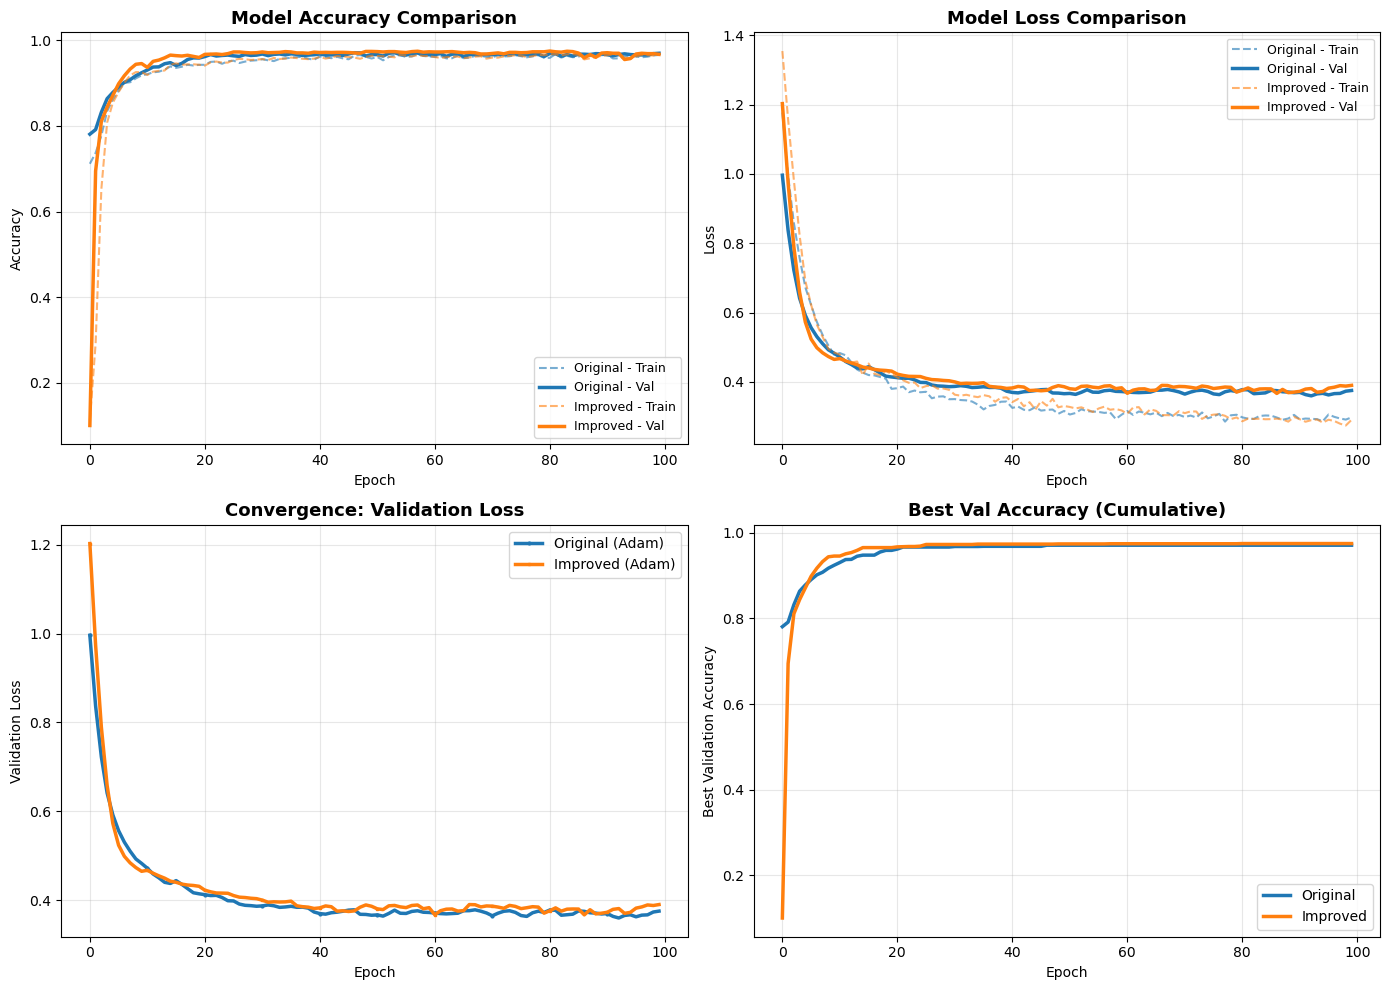


TRAINING SUMMARY - TWO-WAY COMPARISON

📊 Best Validation Accuracy:
  1️⃣  Original (Adam):         0.9712
  2️⃣  Improved (Adam):         0.9751  (++0.39%)

⚡ Convergence Speed (epochs to 95% of best):
  1️⃣  Original (Adam):         10 epochs
  2️⃣  Improved (Adam):         8 epochs  (+2 epochs)

📉 Final Validation Loss:
  1️⃣  Original (Adam):         0.3751
  2️⃣  Improved (Adam):         0.3899  (-3.94%)

⏱️  Average Training Time per Epoch:
  1️⃣  Original (Adam):         0.392s
  2️⃣  Improved (Adam):         0.392s

🏆 WINNER: 2️⃣ Improved (Adam) with 0.9751 val accuracy


In [17]:
# Visualizing comparison between TWO models (Original vs Improved)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy comparison
axes[0, 0].plot(
    history_original["train_acc"], label="Original - Train", linestyle="--", alpha=0.6
)
axes[0, 0].plot(
    history_original["val_acc"], label="Original - Val", linewidth=2.5, color="C0"
)
axes[0, 0].plot(
    history_improved["train_acc"], label="Improved - Train", linestyle="--", alpha=0.6
)
axes[0, 0].plot(
    history_improved["val_acc"], label="Improved - Val", linewidth=2.5, color="C1"
)
axes[0, 0].set_title("Model Accuracy Comparison", fontsize=13, fontweight="bold")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend(loc="lower right", fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

# Loss comparison
axes[0, 1].plot(
    history_original["train_loss"], label="Original - Train", linestyle="--", alpha=0.6
)
axes[0, 1].plot(
    history_original["val_loss"], label="Original - Val", linewidth=2.5, color="C0"
)
axes[0, 1].plot(
    history_improved["train_loss"], label="Improved - Train", linestyle="--", alpha=0.6
)
axes[0, 1].plot(
    history_improved["val_loss"], label="Improved - Val", linewidth=2.5, color="C1"
)
axes[0, 1].set_title("Model Loss Comparison", fontsize=13, fontweight="bold")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].legend(loc="upper right", fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

# Convergence (Validation Loss)
axes[1, 0].plot(
    history_original["val_loss"],
    label="Original (Adam)",
    linewidth=2.5,
    color="C0",
    marker="o",
    markersize=2,
    markevery=10,
)
axes[1, 0].plot(
    history_improved["val_loss"],
    label="Improved (Adam)",
    linewidth=2.5,
    color="C1",
    marker="s",
    markersize=2,
    markevery=10,
)
axes[1, 0].set_title("Convergence: Validation Loss", fontsize=13, fontweight="bold")
axes[1, 0].set_ylabel("Validation Loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].legend(loc="upper right", fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# Best accuracy reached over time
best_acc_orig = [
    max(history_original["val_acc"][: i + 1])
    for i in range(len(history_original["val_acc"]))
]
best_acc_imp = [
    max(history_improved["val_acc"][: i + 1])
    for i in range(len(history_improved["val_acc"]))
]
axes[1, 1].plot(best_acc_orig, label="Original", linewidth=2.5, color="C0")
axes[1, 1].plot(best_acc_imp, label="Improved", linewidth=2.5, color="C1")
axes[1, 1].set_title("Best Val Accuracy (Cumulative)", fontsize=13, fontweight="bold")
axes[1, 1].set_ylabel("Best Validation Accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].legend(loc="lower right", fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== Summary statistics =====
print("\n" + "=" * 70)
print("TRAINING SUMMARY - TWO-WAY COMPARISON")
print("=" * 70)

best_val_orig = max(history_original["val_acc"])
best_val_imp = max(history_improved["val_acc"])

print("\n📊 Best Validation Accuracy:")
print(f"  1️⃣  Original (Adam):         {best_val_orig:.4f}")
print(
    f"  2️⃣  Improved (Adam):         {best_val_imp:.4f}  (+{(best_val_imp - best_val_orig) * 100:+.2f}%)"
)

threshold_orig = best_val_orig * 0.95
threshold_imp = best_val_imp * 0.95

epoch_95_orig = next(
    (i for i, acc in enumerate(history_original["val_acc"]) if acc >= threshold_orig),
    len(history_original["val_acc"]),
)
epoch_95_imp = next(
    (i for i, acc in enumerate(history_improved["val_acc"]) if acc >= threshold_imp),
    len(history_improved["val_acc"]),
)

print("\n⚡ Convergence Speed (epochs to 95% of best):")
print(f"  1️⃣  Original (Adam):         {epoch_95_orig + 1} epochs")
print(
    f"  2️⃣  Improved (Adam):         {epoch_95_imp + 1} epochs  ({(epoch_95_orig - epoch_95_imp):+d} epochs)"
)

print("\n📉 Final Validation Loss:")
print(f"  1️⃣  Original (Adam):         {history_original['val_loss'][-1]:.4f}")
print(
    f"  2️⃣  Improved (Adam):         {history_improved['val_loss'][-1]:.4f}  ({(history_original['val_loss'][-1] - history_improved['val_loss'][-1]) / history_original['val_loss'][-1] * 100:+.2f}%)"
)

print("\n⏱️  Average Training Time per Epoch:")
print(f"  1️⃣  Original (Adam):         {np.mean(history_original['epoch_time']):.3f}s")
print(f"  2️⃣  Improved (Adam):         {np.mean(history_improved['epoch_time']):.3f}s")

winner_idx = int(np.argmax([best_val_orig, best_val_imp]))
winner_names = ["1️⃣ Original (Adam)", "2️⃣ Improved (Adam)"]
print(
    f"\n🏆 WINNER: {winner_names[winner_idx]} with {max(best_val_orig, best_val_imp):.4f} val accuracy"
)
print("=" * 70)

In [18]:
# Prediction function (model outputs logits)
def predict(model, X):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
        logits = model(X_tensor)
        probs = torch.sigmoid(logits)
        predictions = (probs.cpu().numpy() > 0.5).astype(int)
    return predictions


MODEL PERFORMANCE EVALUATION - TWO-WAY COMPARISON


d:\ml\dl_project\.pixi\envs\default\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\imsfp\AppData\Local\Temp\ipykernel_17872\2597235927.py:54: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\ml\dl_project\.pixi\envs\default\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


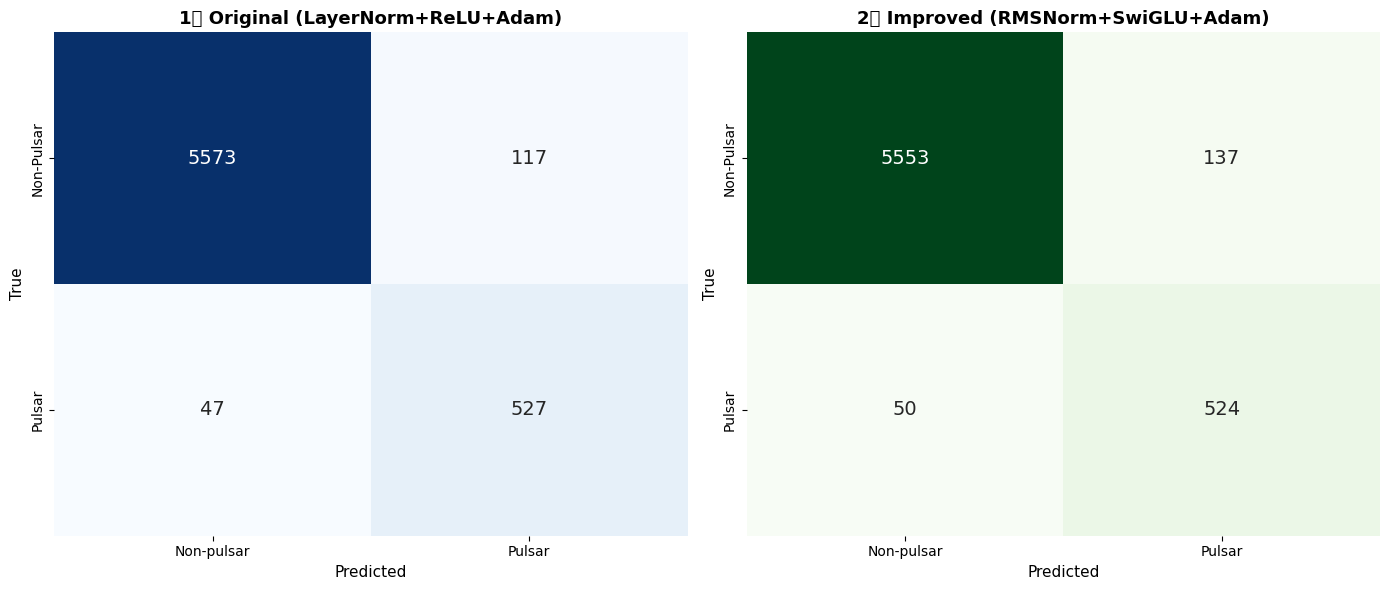


PERFORMANCE METRICS COMPARISON
+------------------------+------------+------------+------------+
|         Model          |  Accuracy  |   Recall   |  F1-Score  |
+------------------------+------------+------------+------------+
|   1️⃣ Original (Adam)   |   0.9738   |   0.9181   |   0.8654   |
|   2️⃣ Improved (Adam)   |   0.9701   |   0.9129   |   0.8486   |
| ────────────────────── | ────────── | ────────── | ────────── |
|    Δ (Model 2 vs 1)    |  +-0.37%   |  +-0.52%   |  +-1.68%   |
+------------------------+------------+------------+------------+

----------------------------------------------------------------------
1️⃣ ORIGINAL MODEL - Detailed Classification Report:
----------------------------------------------------------------------
              precision    recall  f1-score   support

  Non-Pulsar       0.99      0.98      0.99      5690
      Pulsar       0.82      0.92      0.87       574

    accuracy                           0.97      6264
   macro avg       0.90 

In [ ]:
# Performance Evaluation - Compare TWO models
print("\n" + "=" * 70)
print("MODEL PERFORMANCE EVALUATION - TWO-WAY COMPARISON")
print("=" * 70)

THRESHOLD = 0.5

# Get probabilities from both models on TEST set
model_original.eval()
model_improved.eval()

with torch.no_grad():
    X_test_device = torch.tensor(X_test, dtype=torch.float32).to(device)
    prob_original = torch.sigmoid(model_original(X_test_device)).cpu().numpy().ravel()
    prob_improved = torch.sigmoid(model_improved(X_test_device)).cpu().numpy().ravel()

pred_test_orig = (prob_original >= THRESHOLD).astype(int)
pred_test_imp = (prob_improved >= THRESHOLD).astype(int)

# Create TWO confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Model 1: Original
cm_orig = confusion_matrix(y_test, pred_test_orig)
cm_df_orig = pd.DataFrame(
    cm_orig, index=["Non-Pulsar", "Pulsar"], columns=["Non-pulsar", "Pulsar"]
)
sns.heatmap(
    cm_df_orig,
    annot=True,
    fmt="d",
    cbar=False,
    cmap="Blues",
    ax=axes[0],
    annot_kws={"size": 14},
)
axes[0].set_title("1️⃣ Original (LayerNorm+ReLU+Adam)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Predicted", fontsize=11)
axes[0].set_ylabel("True", fontsize=11)

# Model 2: Improved (Adam)
cm_imp = confusion_matrix(y_test, pred_test_imp)
cm_df_imp = pd.DataFrame(
    cm_imp, index=["Non-Pulsar", "Pulsar"], columns=["Non-pulsar", "Pulsar"]
)
sns.heatmap(
    cm_df_imp,
    annot=True,
    fmt="d",
    cbar=False,
    cmap="Greens",
    ax=axes[1],
    annot_kws={"size": 14},
)
axes[1].set_title("2️⃣ Improved (RMSNorm+SwiGLU+Adam)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicted", fontsize=11)
axes[1].set_ylabel("True", fontsize=11)

plt.tight_layout()
plt.show()

# Performance Metrics Comparison Table (TEST)
print("\n" + "=" * 70)
print("PERFORMANCE METRICS COMPARISON")
print("=" * 70)

metrics_comparison = PrettyTable()
metrics_comparison.field_names = ["Model", "Accuracy", "Recall", "F1-Score"]

acc_orig = accuracy_score(y_test, pred_test_orig)
rec_orig = recall_score(y_test, pred_test_orig)
f1_orig = f1_score(y_test, pred_test_orig)

acc_imp = accuracy_score(y_test, pred_test_imp)
rec_imp = recall_score(y_test, pred_test_imp)
f1_imp = f1_score(y_test, pred_test_imp)

metrics_comparison.add_row(
    ["1️⃣ Original (Adam)", f"{acc_orig:.4f}", f"{rec_orig:.4f}", f"{f1_orig:.4f}"]
)
metrics_comparison.add_row(
    ["2️⃣ Improved (Adam)", f"{acc_imp:.4f}", f"{rec_imp:.4f}", f"{f1_imp:.4f}"]
)
metrics_comparison.add_row(["─" * 22, "─" * 10, "─" * 10, "─" * 10])
metrics_comparison.add_row(
    [
        "Δ (Model 2 vs 1)",
        f"+{(acc_imp - acc_orig) * 100:.2f}%",
        f"+{(rec_imp - rec_orig) * 100:.2f}%",
        f"+{(f1_imp - f1_orig) * 100:.2f}%",
    ]
)

print(metrics_comparison)

# Detailed Classification Reports (TEST)
print("\n" + "-" * 70)
print("1️⃣ ORIGINAL MODEL - Detailed Classification Report:")
print("-" * 70)
print(
    classification_report(
        y_test, pred_test_orig, target_names=["Non-Pulsar", "Pulsar"]
    )
)

print("\n" + "-" * 70)
print("2️⃣ IMPROVED MODEL (Adam) - Detailed Classification Report:")
print("-" * 70)
print(
    classification_report(
        y_test, pred_test_imp, target_names=["Non-Pulsar", "Pulsar"]
    )
)

# Select best model for subsequent analysis (use VAL to avoid test leakage)
with torch.no_grad():
    X_val_device = torch.tensor(X_val, dtype=torch.float32).to(device)
    val_prob_original = torch.sigmoid(model_original(X_val_device)).cpu().numpy().ravel()
    val_prob_improved = torch.sigmoid(model_improved(X_val_device)).cpu().numpy().ravel()

val_pred_orig = (val_prob_original >= THRESHOLD).astype(int)
val_pred_imp = (val_prob_improved >= THRESHOLD).astype(int)

val_acc_orig_sel = accuracy_score(y_val, val_pred_orig)
val_acc_imp_sel = accuracy_score(y_val, val_pred_imp)

if val_acc_imp_sel >= val_acc_orig_sel:
    print("\n" + "=" * 70)
    print("✓ IMPROVED (Adam) selected for subsequent analysis (by VAL accuracy).")
    print(f"  VAL acc: {val_acc_imp_sel:.4f} (Improved) vs {val_acc_orig_sel:.4f} (Original)")
    print("=" * 70)
    model = model_improved
    prediction = prob_improved
else:
    print("\n" + "=" * 70)
    print("⚠ ORIGINAL model selected for subsequent analysis (by VAL accuracy).")
    print(f"  VAL acc: {val_acc_orig_sel:.4f} (Original) vs {val_acc_imp_sel:.4f} (Improved)")
    print("=" * 70)
    model = model_original
    prediction = prob_original

print("=" * 70)

## Analysis: Why RMSNorm and SwiGLU?

### 🚀 RMSNorm (Root Mean Square Normalization)
**Advantages over LayerNorm:**
- **Faster**: No mean calculation, only RMS
- **Simpler computation**: `x / sqrt(mean(x²) + ε) * weight`
- **Stable training**: Often improves gradient flow
- **Used in**: LLaMA, GPT-NeoX, PaLM

### 🎯 SwiGLU Activation
**Advantages over ReLU:**
- **Better convergence**: Combines Swish and GLU mechanisms
- **Smoother gradients**: Avoids dead neurons problem
- **Formula**: `SwiGLU(x) = Swish(xW₁) ⊗ (xW₂)`
- **Used in**: LLaMA, PaLM, Switch Transformers

### 🔬 Our Experiment
We compare TWO models (same optimizer: Adam):
1. **Baseline**: LayerNorm + ReLU + Adam
2. **Improved**: RMSNorm + SwiGLU + Adam

This isolates architecture improvements (1 vs 2).

## Test Examples

**Non-pulsar example:**
```
[102.507812, 58.882430, 0.465318, -0.515088, 1.677258, 14.860146, 10.576487, 127.393580]
```

**Pulsar example:**
```
[48.2421875, 36.49202526, 2.935560303, 10.88874578, 41.5041806, 62.89781076, 1.472488674, 1.305269046]
```

In [20]:
# Gradio prediction interface
def predict_pulsar(*features):
    """
    Predict if the celestial object is a pulsar based on input features
    """
    # Convert input features to numpy array format
    features_array = list(features)

    # Apply feature scaling using pre-trained scaler
    scaled = scaler.transform([features_array])

    # Convert to tensor and get prediction
    model.eval()
    with torch.no_grad():
        scaled_tensor = torch.tensor(scaled, dtype=torch.float32).to(device)
        prob = float(torch.sigmoid(model(scaled_tensor)).cpu().numpy()[0][0])

    # Return prediction labels with probabilities
    return {"Non-Pulsar": 1 - prob, "Pulsar": prob}


# Create Gradio web interface
demo = gr.Interface(
    fn=predict_pulsar,
    # Create numerical input fields using dataset column names
    inputs=[gr.Number(label=col) for col in df.columns[:-1]],
    # Configure label output with confidence percentages
    outputs=gr.Label(label="Prediction Result"),
    title="Pulsar Identification System (PyTorch)",
    description="Input eight feature values to predict if the celestial object is a pulsar",
    allow_flagging="never",  # Disable manual result flagging
)

# Launch the web application
demo.launch()

d:\ml\dl_project\.pixi\envs\default\Lib\site-packages\gradio\interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.



--- Noise Sensitivity Analysis ---

Predicting with Noise Level (Std Dev): 0.0
+--------------------+--------------------+--------------------+
|      Accuracy      |       Recall       |      F1-Score      |
+--------------------+--------------------+--------------------+
| 0.9738186462324393 | 0.9181184668989547 | 0.8653530377668309 |
+--------------------+--------------------+--------------------+

Predicting with Noise Level (Std Dev): 0.1
+-------------------+--------------------+--------------------+
|      Accuracy     |       Recall       |      F1-Score      |
+-------------------+--------------------+--------------------+
| 0.972860791826309 | 0.9181184668989547 | 0.8611111111111112 |
+-------------------+--------------------+--------------------+

Predicting with Noise Level (Std Dev): 0.2
+--------------------+--------------------+--------------------+
|      Accuracy      |       Recall       |      F1-Score      |
+--------------------+--------------------+--------------

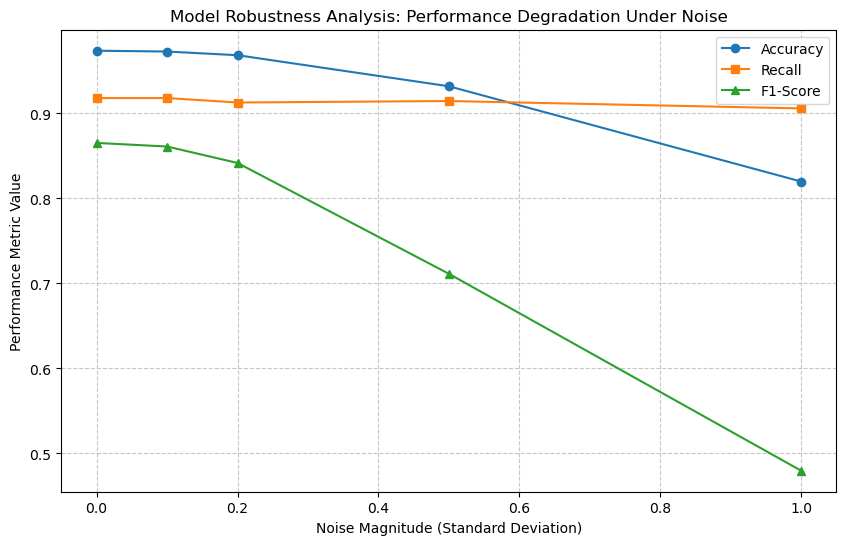

In [21]:
print("\n--- Noise Sensitivity Analysis ---")
# Define different noise standard deviation levels
noise_levels = [0.0, 0.1, 0.2, 0.5, 1.0]
results_noise = {"Noise Level": [], "Accuracy": [], "Recall": [], "F1Score": []}

for std_dev in noise_levels:
    # Generate Gaussian noise with specified standard deviation
    noise = np.random.normal(0, std_dev, X_test.shape)

    # Create noisy test data
    X_test_noisy = X_test + noise

    # Model prediction
    print(f"\nPredicting with Noise Level (Std Dev): {std_dev}")
    prediction_noisy_rounded = predict(model, X_test_noisy)

    # Calculate performance metrics
    acc = accuracy_score(y_test, prediction_noisy_rounded)
    rec = recall_score(y_test, prediction_noisy_rounded)
    f1 = f1_score(y_test, prediction_noisy_rounded)

    # Store results
    results_noise["Noise Level"].append(std_dev)
    results_noise["Accuracy"].append(acc)
    results_noise["Recall"].append(rec)
    results_noise["F1Score"].append(f1)

    # Display formatted results table
    ptbl_noise = PrettyTable()
    ptbl_noise.field_names = ["Accuracy", "Recall", "F1-Score"]
    ptbl_noise.add_row([acc, rec, f1])
    print(ptbl_noise)

# Visualize noise impact on performance metrics
results_df_noise = pd.DataFrame(results_noise)
plt.figure(figsize=(10, 6))
plt.plot(
    results_df_noise["Noise Level"],
    results_df_noise["Accuracy"],
    marker="o",
    label="Accuracy",
)
plt.plot(
    results_df_noise["Noise Level"],
    results_df_noise["Recall"],
    marker="s",
    label="Recall",
)
plt.plot(
    results_df_noise["Noise Level"],
    results_df_noise["F1Score"],
    marker="^",
    label="F1-Score",
)

plt.title("Model Robustness Analysis: Performance Degradation Under Noise")
plt.xlabel("Noise Magnitude (Standard Deviation)")
plt.ylabel("Performance Metric Value")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()